Found 1650 files belonging to 2 classes.
Using 1320 files for training.
Found 1650 files belonging to 2 classes.
Using 330 files for validation.
Index(['filepath', 'label'], dtype='object')


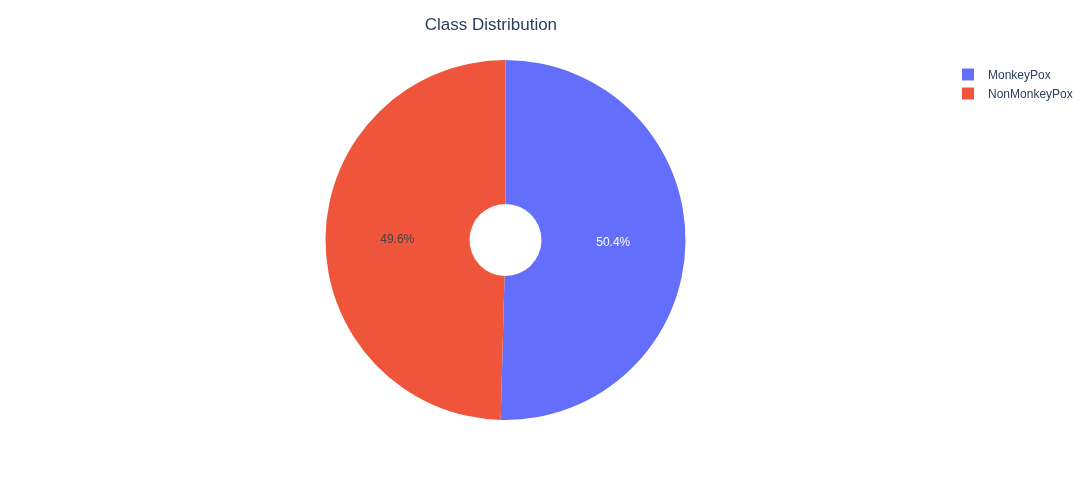

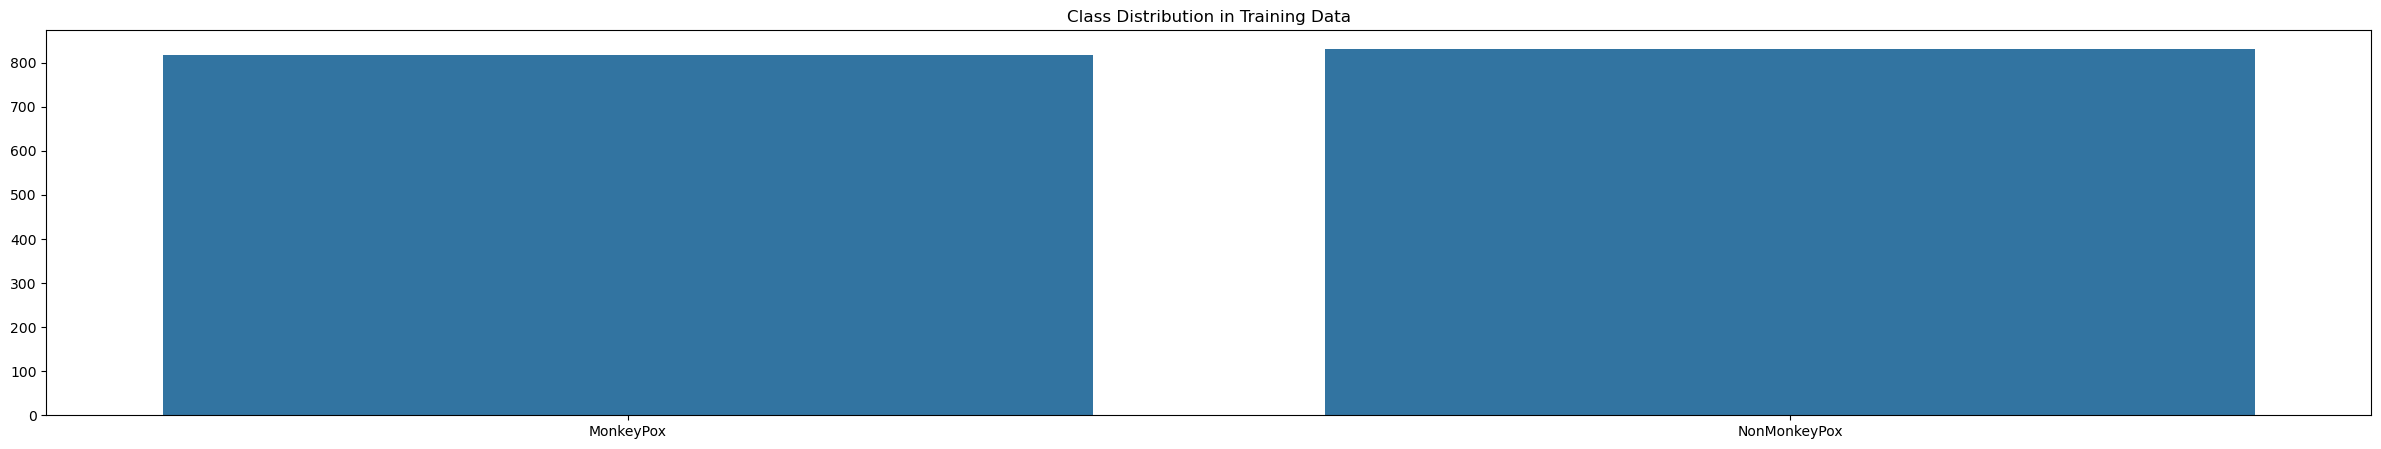

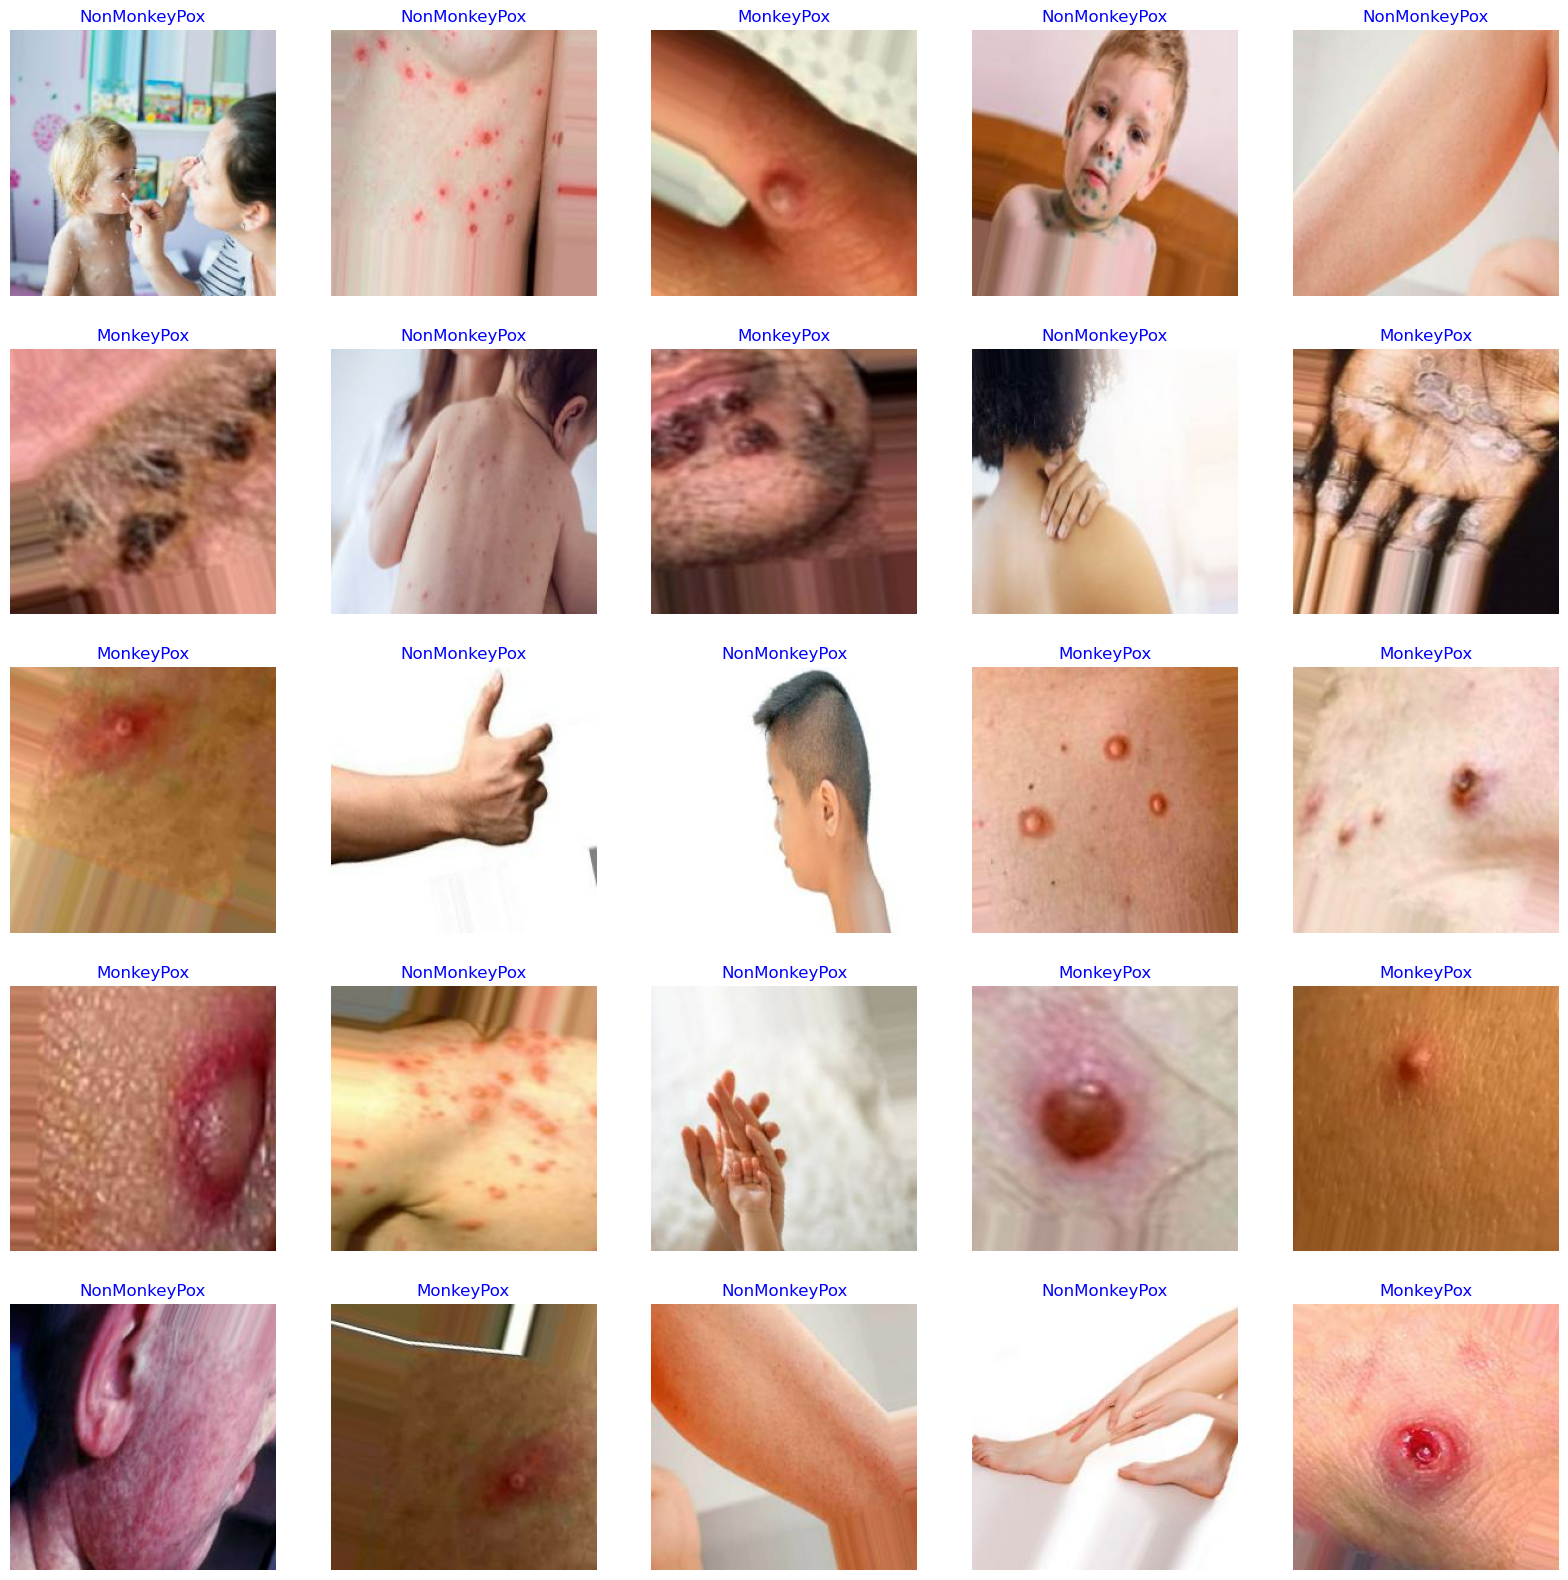

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,706,469 (17.95 MB)

 Trainable params: 656,898 (2.51 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5205 - loss: 0.7440 - val_accuracy: 0.6545 - val_loss: 0.6301
Epoch 2/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.6606 - loss: 0.6304 - val_accuracy: 0.7697 - val_loss: 0.5539
Epoch 3/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7152 - loss: 0.5760 - val_accuracy: 0.8273 - val_loss: 0.4984
Epoch 4/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7614 - loss: 0.5284 - val_accuracy: 0.8636 - val_loss: 0.4568
Epoch 5/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7955 - loss: 0.4842 - val_accuracy: 0.8727 - val_loss: 0.4248
Epoch 6/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8114 - loss: 0.4646 - val_accuracy: 0.8818 - val_loss: 0.3980
Epoch 7/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.8326 - loss: 0.4323 - val_accuracy: 0.8818 - val_loss: 0.3762
Epoch 8/45
42/42 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8356 - loss: 0.4233 - val_accuracy: 0.8788 - val_loss:

In [2]:
# Required Libraries
import numpy as np
import pandas as pd
import os
import glob as gb
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from keras.models import Sequential
from keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import plotly.express as px

# Define image dimensions and batch size
image_height = 224
image_width = 224  # Fixed typo from 'image_weight'
batch_size = 32

# Specify the path to your dataset
tpath = 'aug'  # Update this with your local path if needed

# Load the training and validation data using image_dataset_from_directory
training_data = tf.keras.utils.image_dataset_from_directory(
    tpath,
    batch_size=batch_size,
    image_size=(image_height, image_width),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='training'
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    tpath,
    batch_size=batch_size,
    image_size=(image_height, image_width),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='validation'
)

# Load the metadata information (Update the path if needed)
info_file = 'labels_aug.csv'  # Update the path
info = pd.read_csv(info_file)
info.head()

# Check the column names
print(info.columns)

# Corrected pie chart to use 'label' column (assuming it's lowercase based on your code)
fig = px.pie(
    names=info['label'].unique(),
    values=info['label'].value_counts(),
    hole=0.2,
    width=500,
    height=500
)
fig.update_layout({'title': {'text': 'Class Distribution', 'x': 0.45}})
fig.show()

# Visualize class distribution in a bar plot
class_names = []
class_count = []
train_examples = 0

for f in os.listdir(tpath):
    files = gb.glob(pathname=str(tpath + "//" + f + "/*"))
    class_names.append(f)
    class_count.append(len(files))
    train_examples += len(files)

plt.figure(figsize=(30, 5))
sns.barplot(x=class_names, y=class_count)
plt.title("Class Distribution in Training Data")
plt.show()

# Visualize sample images from the training data
class_names = training_data.class_names  # Get class names from the dataset

# Get a batch of images and labels
images, labels = next(iter(training_data))

# Determine the number of images to display (up to 25)
sample = min(len(labels), 25)

plt.figure(figsize=(20, 20))
for i in range(sample):
    plt.subplot(5, 5, i + 1)
    image = images[i] / 255.0  # Normalize for display
    plt.imshow(image.numpy())
    class_name = class_names[labels[i]]
    plt.title(class_name, color='blue', fontsize=12)
    plt.axis('off')

plt.show()

# Optional: If you have an existing .h5 model and just want to convert to .keras without retraining
# Uncomment and run this section if applicable
# existing_model_path = 'efficientnet.h5'  # Path to your pretrained .h5 file
# model = keras.models.load_model(existing_model_path)
# model.save('efficientnet_converted.keras')  # Save in .keras format
# print("Model converted and saved as .keras")

# Build the EfficientNetB0 model with transfer learning (main training section)
EfficientNet_model = Sequential()

# Load the pre-trained EfficientNetB0 model without the top layers
pretrained_model = keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(image_height, image_width, 3),
    pooling=None,
    weights='imagenet'
)

# Freeze the EfficientNet layers
for layer in pretrained_model.layers:
    layer.trainable = False

EfficientNet_model.add(pretrained_model)
EfficientNet_model.add(GlobalAveragePooling2D())
EfficientNet_model.add(Dropout(0.5))
EfficientNet_model.add(Dense(512, activation='relu'))
EfficientNet_model.add(Dense(2, activation='softmax'))  # Assuming 2 classes based on your code

EfficientNet_model.summary()

# Compile the model
EfficientNet_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.0009),
    metrics=['accuracy']
)

# Train the model
epochs = 45
history_efficientNet = EfficientNet_model.fit(
    training_data,
    validation_data=validation_data,
    epochs=epochs,
    verbose=1
)

# Save the trained model in .keras format
EfficientNet_model.save('efficientnet.keras')
print("Model trained and saved as efficientnet.keras")

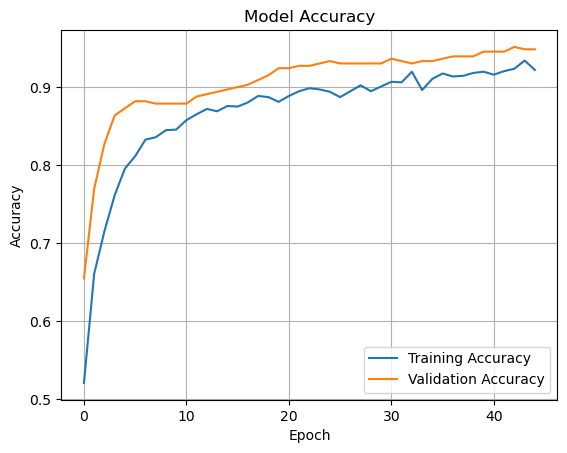

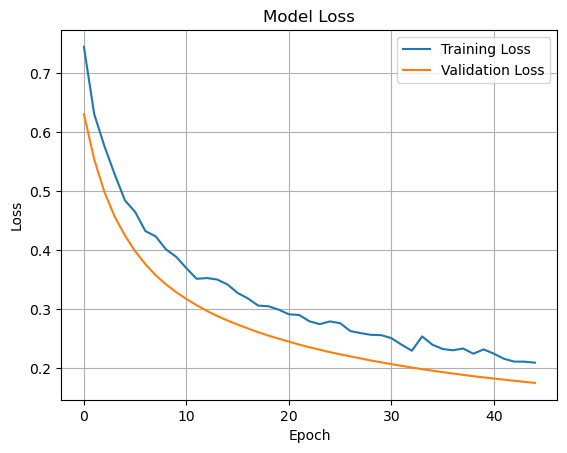

In [3]:
# Visualize training and validation accuracy
import matplotlib.pyplot as plt

plt.plot(history_efficientNet.history['accuracy'], label='Training Accuracy')
plt.plot(history_efficientNet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Visualize training and validation loss
plt.plot(history_efficientNet.history['loss'], label='Training Loss')
plt.plot(history_efficientNet.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()